# Computer Vision Assignment 2 - B00150982


In [38]:
from __future__ import print_function

from tensorflow import keras 
import tensorflow as tf
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, Rescaling, BatchNormalization 
from keras.optimizers import RMSprop,Adam 
import matplotlib.pyplot as plt
import numpy as np

In [39]:
batch_size = 12
num_classes = 3
epochs = 8
img_width = 128
img_height = 128
img_channels = 3
fit = True

train_dir = "c:/Users/diana/Documents/CompVision/dataset/chest_xray/chest_xray/train"
test_dir = "c:/Users/diana/Documents/CompVision/dataset/chest_xray/chest_xray/test"

## Dataset balance

In [40]:
bacterial_count = len(os.listdir(train_dir + "/BACTERIAL"))
normal_count = len(os.listdir(train_dir + "/NORMAL"))
viral_count = len(os.listdir(train_dir + "/VIRAL"))

print("Dataset distribution:")
print("BACTERIAL:", bacterial_count)
print("NORMAL:", normal_count)
print("VIRAL:", viral_count)

total = bacterial_count + normal_count + viral_count
print("Total images:", total)

Dataset distribution:
BACTERIAL: 2596
NORMAL: 1461
VIRAL: 1363
Total images: 5420


## Load dataset

In [41]:
train_ds,val_ds = tf.keras.preprocessing.image_dataset_from_directory(
        train_dir,
        seed=123,
        validation_split=0.2,
        subset='both',
        image_size=(img_height, img_width),
        batch_size=batch_size,
        labels='inferred',
        shuffle=True
)
    
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
        test_dir,
        seed=None,
        image_size=(img_height, img_width),
        batch_size=batch_size,
        labels='inferred',
        shuffle=True
)

class_names = train_ds.class_names
print('Class Names: ',class_names)
num_classes = len(class_names)

Found 5419 files belonging to 3 classes.
Using 4336 files for training.
Using 1083 files for validation.
Found 437 files belonging to 3 classes.
Class Names:  ['BACTERIAL', 'NORMAL', 'VIRAL']


## Visualise images

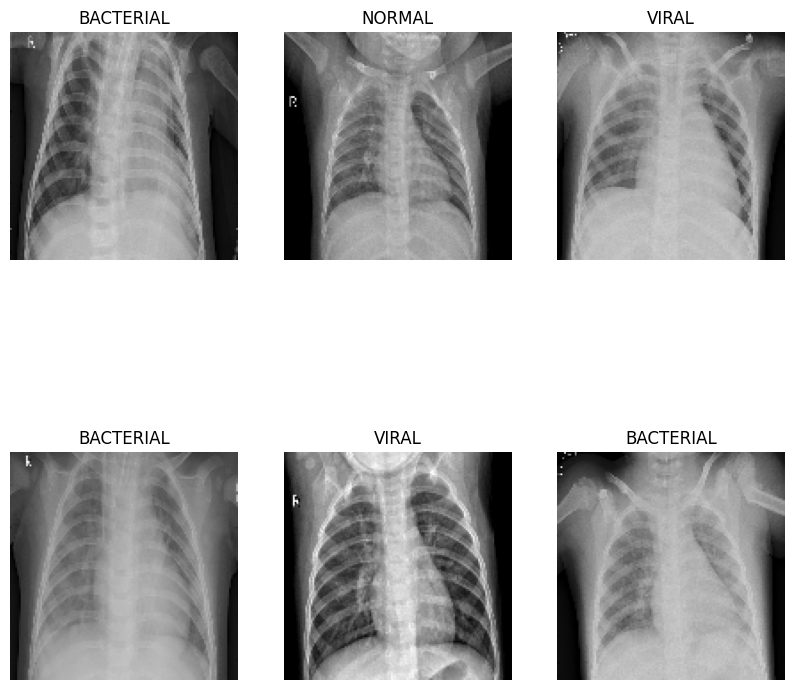

In [42]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(2):
    for i in range(6):
        ax = plt.subplot(2, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy()])
        plt.axis("off")
plt.show()

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.05),
])

In [ ]:
#create model
model = tf.keras.models.Sequential([
    data_augmentation,
    Rescaling(1.0/255),
    Conv2D(16, (3,3), activation = 'relu', input_shape = (img_height,img_width, img_channels)),
    MaxPooling2D(2,2),
    Conv2D(32, (3,3), activation = 'relu'),
    MaxPooling2D(2,2),
    Conv2D(32, (3,3), activation = 'relu'),
    MaxPooling2D(2,2),
    Flatten(), # flatten multidimensional outputs into single dimension for input to dense fully connected layers
    Dense(512, activation = 'relu'),
    Dropout(0.2),
    Dense(num_classes, activation = 'softmax')
])

c:\GitHub\ComputerVision_Assignment2_B00150982\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [44]:
model.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [45]:
save_callback = tf.keras.callbacks.ModelCheckpoint(
    "pneumonia.keras",
    save_best_only=True
)

## Train model

In [46]:
history = model.fit(
        train_ds,
        batch_size=batch_size,
        validation_data=val_ds,
        callbacks=[save_callback],
        epochs=epochs)

Epoch 1/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 47s 124ms/step - accuracy: 0.7179 - loss: 0.6634 - val_accuracy: 0.7618 - val_loss: 0.5619
Epoch 2/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 46s 126ms/step - accuracy: 0.7927 - loss: 0.5001 - val_accuracy: 0.7812 - val_loss: 0.5086
Epoch 3/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 43s 120ms/step - accuracy: 0.8044 - loss: 0.4643 - val_accuracy: 0.7719 - val_loss: 0.5318
Epoch 4/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 43s 118ms/step - accuracy: 0.8183 - loss: 0.4270 - val_accuracy: 0.7812 - val_loss: 0.5249
Epoch 5/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 40s 110ms/step - accuracy: 0.8326 - loss: 0.3927 - val_accuracy: 0.7645 - val_loss: 0.5488
Epoch 6/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 45s 124ms/step - accuracy: 0.8466 - loss: 0.3522 - val_accuracy: 0.7692 - val_loss: 0.5724
Epoch 7/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 44s 120ms/step - accuracy: 0.8706 - loss: 0.3085 - val_accuracy: 0.7664 - val_loss: 0.5838
Epoch 8/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 46s 126ms/step - accuracy: 0.8879 - loss: 0.2613 - 

## Evaluate model

In [47]:
score = model.evaluate(test_ds, batch_size=batch_size)
print('Test accuracy:', score[1])

37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.7391 - loss: 0.7962
Test accuracy: 0.739130437374115


## Plot accuracy

C:\Users\diana\AppData\Local\Temp\ipykernel_29056\293871340.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


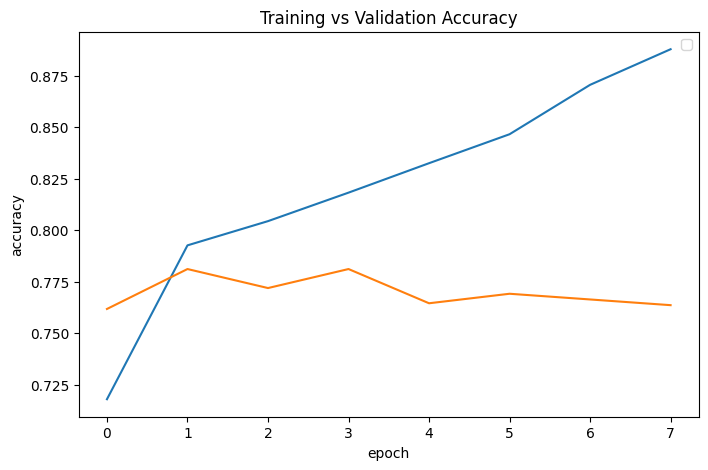

In [48]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Training vs Validation Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend()
plt.show()

C:\Users\diana\AppData\Local\Temp\ipykernel_29056\2512735038.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


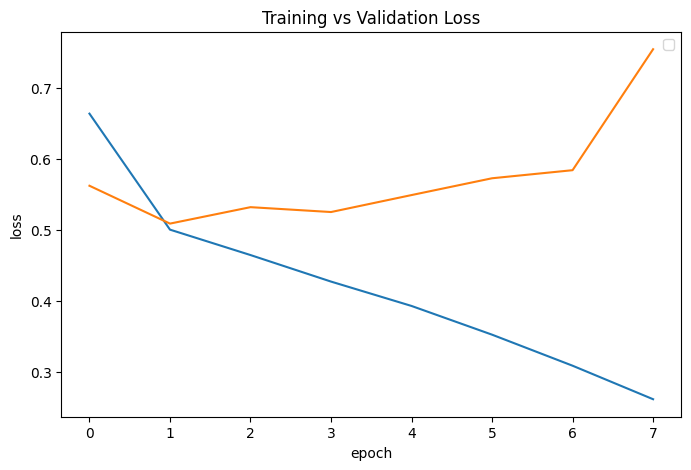

In [53]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Training vs Validation Loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend()
plt.show()

## Predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


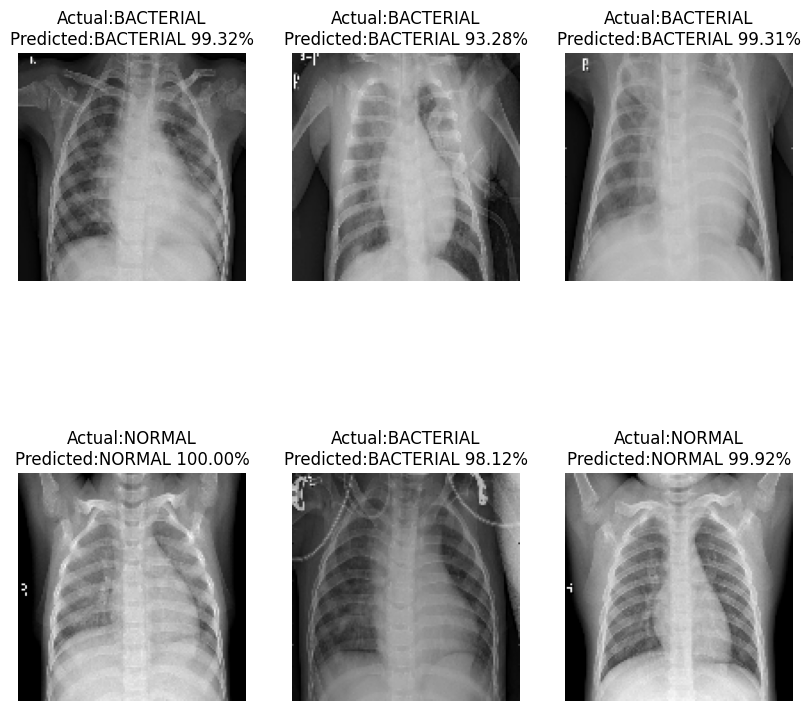

In [51]:
test_batch = test_ds.take(1)
plt.figure(figsize=(10, 10))
for images, labels in test_batch:
    for i in range(6):
        ax = plt.subplot(2, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        prediction = model.predict(tf.expand_dims(images[i].numpy(),0))#perform a prediction on this image
        plt.title('Actual:' + class_names[labels[i].numpy()]+ '\nPredicted:{} {:.2f}%'.format(class_names[np.argmax(prediction)], 100 * np.max(prediction)))
        plt.axis("off")
    plt.show()